In [44]:
import numpy as np
FileName = input("Give the filename of your File:")
x, y = np.loadtxt(FileName, unpack=True)
print(f"{x}with mean: {np.mean(x)}, max: {np.max(x)} and min: {np.min(x)}")
print(f"{y}with mean: {np.mean(y)}, max: {np.max(y)} and min: {np.min(y)}")
y2 = (y - np.median(y))**2
print(y2)

Give the filename of your File: Data Thing.ASCII


[ 1. 20. 30. 20.  1.  2.  6.  2.  6.  3.]with mean: 9.1, max: 30.0 and min: 1.0
[20.  1.  1. 22.  3.  5.  1.  4.  4.  9.]with mean: 7.0, max: 22.0 and min: 1.0
[256.   9.   9. 324.   1.   1.   9.   0.   0.  25.]


# 5.6

In [44]:
import numpy as np

a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
c = np.concatenate((a, b))
print(c) #1D plot


[1 2 3 4 5 6]


In [49]:
import numpy as np

a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])

x = np.concatenate((a, b)) #2D
y = np.concatenate((a, b), axis=0) #2D
z = np.concatenate((a, b), axis=1) #4D

print(x)
print(y)
print(z)

[[1 2]
 [3 4]
 [5 6]
 [7 8]]
[[1 2]
 [3 4]
 [5 6]
 [7 8]]
[[1 2 5 6]
 [3 4 7 8]]


# 5.9

255


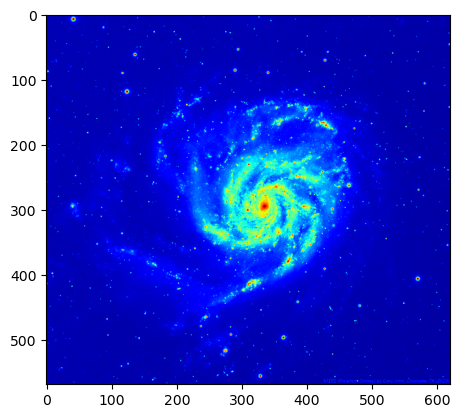

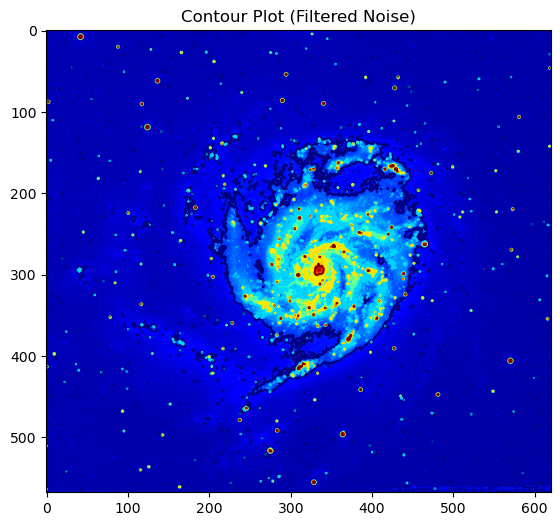

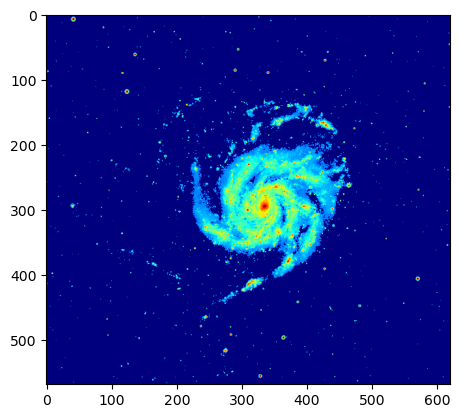

In [54]:
import imageio.v2 as img
import numpy as np
import matplotlib.pyplot as plt
y = img.imread("m101BW.jpg")
print(np.max(y))

threshold = np.percentile(y, 90)
Filtered_Data = np.where(y >= threshold, y, 0)

plt.imshow(y, cmap = "jet")
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(y, cmap = "jet")
plt.contour(y, levels=[50, 100, 150, 200], cmap='jet')
plt.title("Contour Plot (Filtered Noise)")
plt.show()

plt.imshow(Filtered_Data, cmap ="jet")
plt.show()

Max: 0.06
Min: 0.00
Sum: 0.89
Mean: 0.02
Std Dev: 0.01


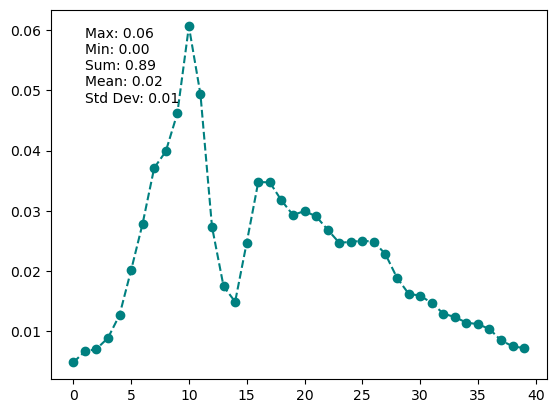

In [81]:
import numpy as np
import matplotlib.pyplot as plt

y = np.loadtxt("ngc6946.txt")
data = y.reshape(40,50,70)

z_prof = data[:, 25, 35]

stats = {
    "Max": np.max(z_prof),
    "Min": np.min(z_prof),
    "Sum": np.sum(z_prof),
    "Mean": np.mean(z_prof),
    "Std Dev": np.std(z_prof)
}
plt.plot(z_prof, marker='o', linestyle='--', color='teal', label='Z-Profile')
stats_text = "\n".join([f"{k}: {v:.2f}" for k, v in stats.items()])
print(stats_text)
plt.text(1, stats["Max"], stats_text, fontsize=10, verticalalignment='top')
plt.show()


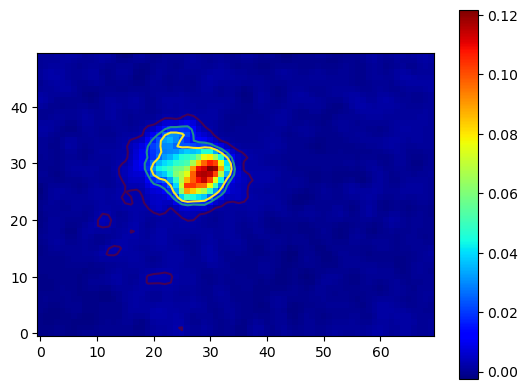

In [94]:
import numpy as np
import matplotlib.pyplot as plt

y = np.loadtxt("ngc6946.txt")
data = y.reshape(40,50,70)[0]

m = np.mean(data)
s = np.std(data)
levels = [m, m + s, m + 2 * s]

plt.imshow(data,cmap="jet", origin='lower')
plt.colorbar()
plt.contour(data, levels)
plt.show()

In [18]:
import numpy as np
from scipy.constants import c

class Galaxy:    
    """Class for redshift calculation of galaxies"""  
        
    caH_0 = 3968.5      # Calcium H line in rest frame
    Vc = c / 1000
    
    def __init__(self, name, calciumHline=caH_0):
        self.name = name
        self.caH = calciumHline
    
    def redshift(self):        
        z = (self.caH - self.caH_0)/self.caH
        return z
    
    def velocity(self):
        """Returns the velocity of the galaxy in km/s"""
        z = self.redshift()
        return z * self.Vc
    

my_galaxy = Galaxy("Andromeda", calciumHline=4000.0)

V = my_galaxy.velocity()
print(f"Galaxy: {my_galaxy.name}")
print(f"Recession Velocity: {V:.2f} km/s")

Galaxy: Andromeda
Recession Velocity: 2360.87 km/s


# 5.13

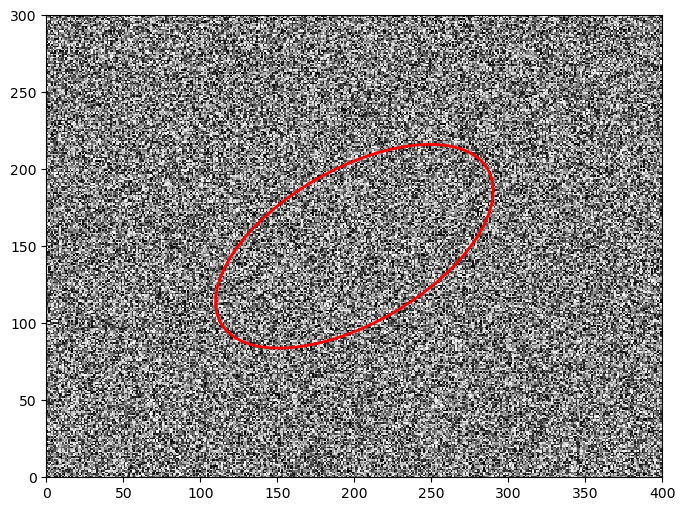

In [52]:
import numpy as np
from matplotlib.pyplot import figure, show
import matplotlib.patches as patches

# 1. Create dummy 2D array
Nx = 400
Ny = 300
data = np.random.random((Ny, Nx))

fig = figure(figsize=(8, 6))
ax = fig.add_subplot(111)

# Plot the 2D data
ax.imshow(data, interpolation='none', origin='lower', cmap='gray')

ellipse = patches.Ellipse( xy=(Nx/2, Ny/2), width=200, height=100, angle=30.0, edgecolor='red', facecolor='none', linewidth=2)

ax.add_patch(ellipse)
ax.set_xlim(0, Nx)
ax.set_ylim(0, Ny)

show()